# 2_ber_analysis.ipynb

## 透明转发架构下 LEO 卫星下行链路：单用户 BER 性能分析

本 notebook 基于原 `BER_sims.ipynb` 的链路结构整理，保持：

- 单卫星；
- 单用户；
- 单天线；
- 下行链路；
- OFDM；
- QPSK；
- 3GPP TR 38.811 NTN 信道；
- LS / perfect CSI + LMMSE equalization；
- uncoded BER 或 coded BER。

中期答辩建议优先展示 uncoded BER，因为趋势更稳定、运行更快、解释更直接。

In [1]:
%%bash
# ============================================================
# 安装环境（运行完后必须重启运行时！）
# ============================================================

# 1. 安装 sionna 1.x（OpenNTN 兼容版本，原生有 log10，无需补丁）
pip install "sionna>=1.0,<2.0" -q

# 2. 安装 OpenNTN
pip install git+https://github.com/ant-uni-bremen/OpenNTN@main -q

# 3. 运行 post_install
curl -sL -o post_install.py \
  https://raw.githubusercontent.com/ant-uni-bremen/OpenNTN/refs/heads/main/post_install.py
python post_install.py

# 4. 创建 tr38811 软链接
OpenNTN_DIR=$(pip show OpenNTN | grep Location | cut -d' ' -f2)/OpenNTN
SIONNA_DIR=$(pip show sionna  | grep Location | cut -d' ' -f2)/sionna
ln -sf "$OpenNTN_DIR" "$SIONNA_DIR/phy/channel/tr38811"

# 5. 验证
python -c "from sionna.phy.channel.tr38811 import DenseUrban; print('OK, sionna', __import__('sionna').__version__)"
rm -f post_install.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.0 MB/s eta 0:00:00
Added import of tr38811 in channel: from . import tr38811
ran the installer file
the framework was found at  /usr/local/lib/python3.12/dist-packages
sionna path is:  /usr/local/lib/python3.12/dist-packages/sionna/phy/channel
OK, sionna 1.2.2


/content/post_install.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
2026-04-28 06:05:16.743246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777356316.774225    5895 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777356316.781173    5895 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777356316.796803    5895 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777356316.796835    5895 computation_placer.cc:177] computation placer already 

## ⚠️ 运行上面的安装 cell 后，必须重启运行时！

`运行时 → 重新启动运行时`（或 Ctrl+M .）

重启后从下面的 Cell 1 开始继续运行，**不要**重新运行安装 cell。

In [4]:
# Cell 1：导入库与环境设置

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

gpu_num = 0
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

from sionna.phy import Block
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers
from sionna.phy.mimo import StreamManagement
from sionna.phy.channel.tr38811 import AntennaArray, DenseUrban, Urban, SubUrban
from sionna.phy.channel.tr38811.utils import gen_single_sector_topology as gen_ntn_topology
from sionna.phy.utils import ebnodb2no, sim_ber
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource
from sionna.phy.channel import OFDMChannel

tf.get_logger().setLevel("ERROR")
np.random.seed(1)
tf.random.set_seed(1)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


### Cell 1 作用

导入 BER 仿真需要的模块。  
这个 notebook 沿用原 `BER_sims.ipynb` 的 Sionna 链路模块，包括 `ResourceGrid`、`OFDMChannel`、`LSChannelEstimator`、`LMMSEEqualizer`、`LDPC5GEncoder/Decoder` 和 `sim_ber`。

In [5]:
# Cell 2：统一系统参数

BASE_CONFIG = {
    "direction": "downlink",
    "num_ut": 1,
    "num_ut_ant": 1,
    "num_bs_ant": 1,
    "sat_height": 600000.0,

    "fft_size": 52 * 12,
    "subcarrier_spacing": 15e3,
    "num_ofdm_symbols": 12,
    "cyclic_prefix_length": 10,
    # 修复：从 [2] 改为 [1, 6, 11]，让 LS 估计器有足够的时域导频覆盖
    # 多普勒下信道逐符号变化，单个导频做 nn 插值会导致 BER=0.5
    "pilot_ofdm_symbol_indices": [1, 6, 11],

    "num_bits_per_symbol": 2,
    "coderate": 526.0 / 1024.0,

    "scenario": "dur",
    "carrier_frequency": 3.5e9,
    "elevation_angle": 50.0,

    "ebno_db": np.arange(-2.0, 16.1, 2.0),
    "batch_size": 8,
    "max_mc_iter": 50,
    "num_target_block_errors": 50,
}

print(BASE_CONFIG)

{'direction': 'downlink', 'num_ut': 1, 'num_ut_ant': 1, 'num_bs_ant': 1, 'sat_height': 600000.0, 'fft_size': 624, 'subcarrier_spacing': 15000.0, 'num_ofdm_symbols': 12, 'cyclic_prefix_length': 10, 'pilot_ofdm_symbol_indices': [1, 6, 11], 'num_bits_per_symbol': 2, 'coderate': 0.513671875, 'scenario': 'dur', 'carrier_frequency': 3500000000.0, 'elevation_angle': 50.0, 'ebno_db': array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14., 16.]), 'batch_size': 8, 'max_mc_iter': 50, 'num_target_block_errors': 50}


### Cell 2 作用

集中管理参数，避免后面不同实验混用上行/下行或多用户配置。  
如果运行太慢，可以先把 `max_mc_iter` 和 `num_target_block_errors` 降到 100，跑通趋势后再加大。

In [6]:
# Cell 3：单用户下行 NTN OFDM BER 模型

class SingleUserNTNDownlinkBER(Block):
    """
    单用户 LEO NTN 下行链路 BER 仿真模型。
    """

    def __init__(self,
                 scenario="dur",
                 carrier_frequency=3.5e9,
                 elevation_angle=50.0,
                 doppler_enabled=True,
                 enable_pathloss=True,
                 enable_shadow_fading=True,
                 perfect_csi=True,
                 coded_ber=False,
                 config=BASE_CONFIG):
        super().__init__()

        self._scenario = scenario
        self._carrier_frequency = carrier_frequency
        self._elevation_angle = elevation_angle
        self._doppler_enabled = doppler_enabled
        self._enable_pathloss = enable_pathloss
        self._enable_shadow_fading = enable_shadow_fading
        self._perfect_csi = perfect_csi
        self._coded_ber = coded_ber

        self._direction = config["direction"]
        self._num_ut = config["num_ut"]
        self._num_ut_ant = config["num_ut_ant"]
        self._num_bs_ant = config["num_bs_ant"]
        self._sat_height = config["sat_height"]

        self._fft_size = config["fft_size"]
        self._subcarrier_spacing = config["subcarrier_spacing"]
        self._num_ofdm_symbols = config["num_ofdm_symbols"]
        self._cyclic_prefix_length = config["cyclic_prefix_length"]
        self._pilot_ofdm_symbol_indices = config["pilot_ofdm_symbol_indices"]

        self._num_bits_per_symbol = config["num_bits_per_symbol"]
        self._coderate = config["coderate"]

        if self._direction != "downlink":
            raise ValueError("本 notebook 固定为 downlink，不建议混入 uplink。")

        self._num_tx = 1
        self._num_streams_per_tx = self._num_bs_ant

        rx_tx_association = np.zeros([self._num_ut, 1])
        rx_tx_association[:, 0] = 1
        self._rx_tx_association = rx_tx_association

        self._rg = ResourceGrid(
            num_ofdm_symbols=self._num_ofdm_symbols,
            fft_size=self._fft_size,
            subcarrier_spacing=self._subcarrier_spacing,
            num_tx=self._num_tx,
            num_streams_per_tx=self._num_streams_per_tx,
            cyclic_prefix_length=self._cyclic_prefix_length,
            pilot_pattern="kronecker",
            pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices,
        )

        self._sm = StreamManagement(self._rx_tx_association, self._num_streams_per_tx)

        self._ut_array = AntennaArray(
            num_rows=1,
            num_cols=self._num_ut_ant,
            polarization="single",
            polarization_type="V",
            antenna_pattern="omni",
            carrier_frequency=self._carrier_frequency,
        )

        self._bs_array = AntennaArray(
            num_rows=1,
            num_cols=self._num_bs_ant,
            polarization="single",
            polarization_type="V",
            antenna_pattern="aperture",
            carrier_frequency=self._carrier_frequency,
        )

        cls_map = {
            "dur": DenseUrban,
            "urb": Urban,
            "sur": SubUrban,
        }
        if scenario not in cls_map:
            raise ValueError(f"Unknown scenario: {scenario}")

        self._channel_model = cls_map[scenario](
            carrier_frequency=self._carrier_frequency,
            ut_array=self._ut_array,
            bs_array=self._bs_array,
            direction=self._direction,
            elevation_angle=self._elevation_angle,
            enable_pathloss=self._enable_pathloss,
            enable_shadow_fading=self._enable_shadow_fading,
            doppler_enabled=self._doppler_enabled,
        )

        self._binary_source = BinarySource()
        self._n = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._k = int(self._n * self._coderate)

        self._encoder = LDPC5GEncoder(self._k, self._n)
        self._decoder = LDPC5GDecoder(self._encoder)

        self._mapper = Mapper("qam", self._num_bits_per_symbol)
        self._rg_mapper = ResourceGridMapper(self._rg)

        self._ofdm_channel = OFDMChannel(
            self._channel_model,
            self._rg,
            add_awgn=True,
            normalize_channel=True,
            return_channel=True,
        )

        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg)
        self._ls_est = LSChannelEstimator(self._rg, interpolation_type="nn")
        self._lmmse_equ = LMMSEEqualizer(self._rg, self._sm)

        if self._coded_ber:
            self._demapper = Demapper("app", "qam", self._num_bits_per_symbol, hard_out=False)
        else:
            self._demapper = Demapper("app", "qam", self._num_bits_per_symbol, hard_out=True)

    def new_topology(self, batch_size):
        topology = gen_ntn_topology(
            batch_size=batch_size,
            num_ut=self._num_ut,
            scenario=self._scenario,
            bs_height=self._sat_height,
            elevation_angle=self._elevation_angle,
        )
        self._channel_model.set_topology(*topology)

    @tf.function(jit_compile=False)
    def call(self, batch_size, ebno_db):
        self.new_topology(batch_size)

        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)
        no = no * self._num_bits_per_symbol

        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])
        c = self._encoder(b)

        x = self._mapper(c)
        x_rg = self._rg_mapper(x)

        y, h = self._ofdm_channel(x_rg, no)

        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = 0.0
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)
        llr_or_bits = self._demapper(x_hat, no_eff)

        if self._coded_ber:
            b_hat = self._decoder(llr_or_bits)
            return b, b_hat
        else:
            c_hat = llr_or_bits
            return c, c_hat

### Cell 3 作用

定义 BER 仿真模型。  
这里比原 `BER_sims.ipynb` 多暴露了 `carrier_frequency`，方便用载波频率构造不同多普勒强度。

注意：

- `coded_ber=False` 时，统计解调后的 coded bits 和编码器输出 bits 之间的误码率，本质是 pre-decoder / uncoded BER；
- `coded_ber=True` 时，统计 LDPC decoder 后的信息比特 BER，运行更慢，但更接近完整链路。

In [7]:
# Cell 4：BER 仿真工具函数

def run_ber_curve(label,
                  scenario="dur",
                  carrier_frequency=3.5e9,
                  elevation_angle=50.0,
                  doppler_enabled=True,
                  enable_pathloss=False,
                  enable_shadow_fading=False,
                  perfect_csi=True,
                  coded_ber=False,
                  ebno_db=None,
                  batch_size=None,
                  max_mc_iter=None,
                  num_target_block_errors=None,
                  save_pickle=None):
    """
    运行一条 BER 曲线，并返回结果字典。
    """
    if ebno_db is None:
        ebno_db = BASE_CONFIG["ebno_db"]
    if batch_size is None:
        batch_size = BASE_CONFIG["batch_size"]
    if max_mc_iter is None:
        max_mc_iter = BASE_CONFIG["max_mc_iter"]
    if num_target_block_errors is None:
        num_target_block_errors = BASE_CONFIG["num_target_block_errors"]

    print(f"\nRunning: {label}")
    print(f"scenario={scenario}, fc={carrier_frequency/1e9:.2f} GHz, elevation={elevation_angle}, doppler={doppler_enabled}, pathloss={enable_pathloss}")

    model = SingleUserNTNDownlinkBER(
        scenario=scenario,
        carrier_frequency=carrier_frequency,
        elevation_angle=elevation_angle,
        doppler_enabled=doppler_enabled,
        enable_pathloss=enable_pathloss,
        enable_shadow_fading=enable_shadow_fading,
        perfect_csi=perfect_csi,
        coded_ber=coded_ber,
    )

    start = time.time()

    ber, bler = sim_ber(
        model,
        ebno_db,
        batch_size=batch_size,
        max_mc_iter=max_mc_iter,
        num_target_block_errors=num_target_block_errors,
    )

    duration = time.time() - start

    result = {
        "label": label,
        "ebno_db": np.array(ebno_db),
        "ber": ber.numpy(),
        "bler": bler.numpy(),
        "duration": duration,
        "scenario": scenario,
        "carrier_frequency": carrier_frequency,
        "elevation_angle": elevation_angle,
        "doppler_enabled": doppler_enabled,
        "enable_pathloss": enable_pathloss,
        "enable_shadow_fading": enable_shadow_fading,
        "perfect_csi": perfect_csi,
        "coded_ber": coded_ber,
    }

    print(f"Finished {label}, duration = {duration:.1f} s")

    if save_pickle is not None:
        with open(save_pickle, "wb") as f:
            pickle.dump(result, f)

    return result


def plot_ber_results(results, title):
    plt.figure(figsize=(7, 5))
    for r in results:
        plt.semilogy(r["ebno_db"], r["ber"], marker="o", label=r["label"])

    plt.xlabel(r"$E_b/N_0$ (dB)")
    plt.ylabel("BER")
    plt.title(title)
    plt.grid(True, which="both")
    plt.legend()
    plt.ylim([1e-4, 1])
    plt.tight_layout()
    plt.show()

### Cell 4 作用

封装 BER 曲线运行与画图函数。  
`enable_pathloss=False` 是 BER 对比实验中的推荐默认值：这样不同曲线差异主要来自小尺度信道、多普勒、LOS 条件等，而不是大尺度路径损耗导致的 SNR 平移。


Running: No Doppler, LS est.
scenario=dur, fc=3.50 GHz, elevation=50.0, doppler=False, pathloss=False
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -2.0 | 4.2670e-01 | 1.0000e+00 |      268391 |      628992 |           56 |          56 |        33.2 |reached target block errors
      0.0 | 3.9094e-01 | 1.0000e+00 |      245901 |      628992 |           56 |          56 |         0.3 |reached target block errors
      2.0 | 3.4178e-01 | 1.0000e+00 |      214974 |      628992 |           56 |          56 |         0.3 |reached target block errors
      4.0 | 2.8586e-01 | 1.0000e+00 |      179803 |      628992 |           56 |          56 |         0.3 |reached target block errors
      6.0 | 2.1808e-01 | 1.0000e+00 |      137172 |      628992 |           56 |          56 |    

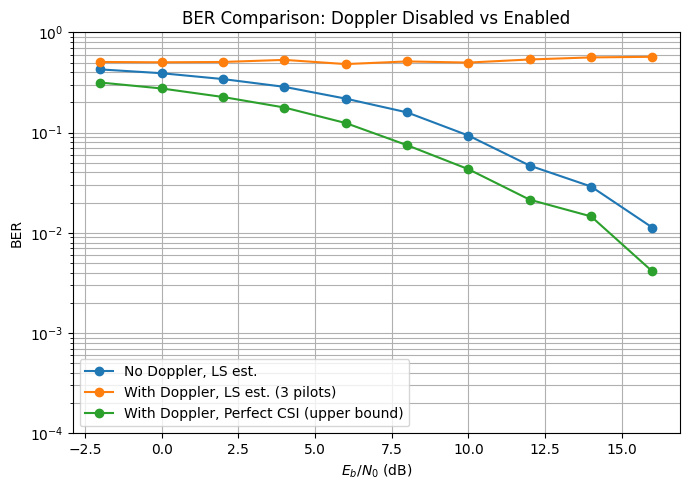

In [8]:
# Cell 5：BER 图 1a —— 是否启用多普勒

ebno_db = BASE_CONFIG["ebno_db"]

doppler_on_off_results = []

# 四条曲线：
#  1. 无多普勒 + LS估计（基准）
#  2. 有多普勒 + LS估计（修复后：3个导频符号，可正常估计时变信道）
#  3. 有多普勒 + Perfect CSI（理想上界，排除估计误差的影响）
doppler_on_off_cases = [
    {
        "label": "No Doppler, LS est.",
        "carrier_frequency": 3.5e9,
        "doppler_enabled": False,
        "perfect_csi": False,
    },
    {
        "label": "With Doppler, LS est. (3 pilots)",
        "carrier_frequency": 3.5e9,
        "doppler_enabled": True,
        "perfect_csi": False,
    },
    {
        "label": "With Doppler, Perfect CSI (upper bound)",
        "carrier_frequency": 3.5e9,
        "doppler_enabled": True,
        "perfect_csi": True,
    },
]

for case in doppler_on_off_cases:
    res = run_ber_curve(
        label=case["label"],
        scenario="dur",
        carrier_frequency=case["carrier_frequency"],
        elevation_angle=50.0,
        doppler_enabled=case["doppler_enabled"],
        enable_pathloss=False,
        enable_shadow_fading=False,
        perfect_csi=case["perfect_csi"],
        coded_ber=False,
        ebno_db=ebno_db,
    )
    doppler_on_off_results.append(res)

plot_ber_results(doppler_on_off_results, "BER Comparison: Doppler Disabled vs Enabled")

### BER 图 1a 物理意义

这张图只比较 `doppler_enabled=False` 和 `doppler_enabled=True`。

解释方式：

- 关闭多普勒时，信道在一个 OFDM 帧内近似静态，信道估计和均衡更容易；
- 开启多普勒后，信道随时间变化，可能造成相位旋转、信道估计过时和子载波间干扰；
- 因此同等 Eb/N0 下，启用多普勒的 BER 通常更差，尤其高 SNR 区域可能出现性能损失或误码平台。


Running: Doppler, 2 GHz
scenario=dur, fc=2.00 GHz, elevation=50.0, doppler=True, pathloss=False
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -2.0 | 3.1527e-01 | 1.0000e+00 |      198302 |      628992 |           56 |          56 |         6.8 |reached target block errors
      0.0 | 2.7682e-01 | 1.0000e+00 |      174115 |      628992 |           56 |          56 |         0.4 |reached target block errors
      2.0 | 2.2791e-01 | 1.0000e+00 |      143352 |      628992 |           56 |          56 |         0.3 |reached target block errors
      4.0 | 1.7636e-01 | 1.0000e+00 |      110931 |      628992 |           56 |          56 |         0.3 |reached target block errors
      6.0 | 1.2021e-01 | 1.0000e+00 |       75614 |      628992 |           56 |          56 |         0

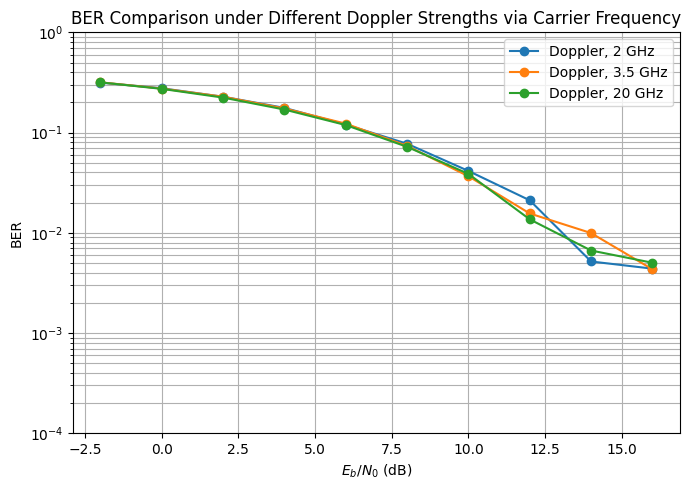

In [9]:
# Cell 6：BER 图 1b —— 通过载波频率间接控制多普勒强度

doppler_strength_results = []

doppler_strength_cases = [
    {"label": "Doppler, 2 GHz", "carrier_frequency": 2.0e9},
    {"label": "Doppler, 3.5 GHz", "carrier_frequency": 3.5e9},
    {"label": "Doppler, 20 GHz", "carrier_frequency": 20.0e9},
]

for case in doppler_strength_cases:
    res = run_ber_curve(
        label=case["label"],
        scenario="dur",
        carrier_frequency=case["carrier_frequency"],
        elevation_angle=50.0,
        doppler_enabled=True,
        enable_pathloss=False,
        enable_shadow_fading=False,
        perfect_csi=True,   # 修复：用 perfect CSI 展示不同多普勒强度的纯信道效应
        coded_ber=False,
        ebno_db=ebno_db,
    )
    doppler_strength_results.append(res)

plot_ber_results(doppler_strength_results, "BER Comparison under Different Doppler Strengths via Carrier Frequency")

### BER 图 1b 物理意义

多普勒频移近似满足 `f_D = v_rel * f_c / c`。  
在不直接改 topology 速度张量的情况下，可以通过提高载波频率 `f_c` 间接增大多普勒频移。

答辩时必须说明：这里不是直接改变卫星速度，而是在相同拓扑运动条件下通过载波频率改变多普勒强度。


Running: Low elevation 10 deg
scenario=dur, fc=3.50 GHz, elevation=10.0, doppler=True, pathloss=False
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -2.0 | 3.1999e-01 | 1.0000e+00 |      201269 |      628992 |           56 |          56 |         6.4 |reached target block errors
      0.0 | 2.7876e-01 | 1.0000e+00 |      175338 |      628992 |           56 |          56 |         0.3 |reached target block errors
      2.0 | 2.3235e-01 | 1.0000e+00 |      146147 |      628992 |           56 |          56 |         0.3 |reached target block errors
      4.0 | 1.8081e-01 | 1.0000e+00 |      113730 |      628992 |           56 |          56 |         0.3 |reached target block errors
      6.0 | 1.3202e-01 | 1.0000e+00 |       83040 |      628992 |           56 |          56 |    

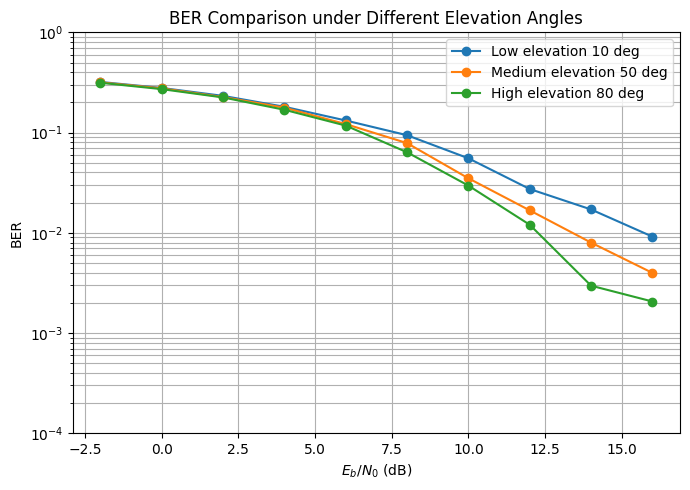

In [10]:
# Cell 7：BER 图 2 —— 用仰角替代 LOS / K 因子强弱

elevation_results = []

elevation_cases = [
    {"label": "Low elevation 10 deg", "elevation_angle": 10.0},
    {"label": "Medium elevation 50 deg", "elevation_angle": 50.0},
    {"label": "High elevation 80 deg", "elevation_angle": 80.0},
]

for case in elevation_cases:
    res = run_ber_curve(
        label=case["label"],
        scenario="dur",
        carrier_frequency=3.5e9,
        elevation_angle=case["elevation_angle"],
        doppler_enabled=True,
        enable_pathloss=False,
        enable_shadow_fading=False,
        perfect_csi=True,   # 修复：用 perfect CSI 展示不同仰角的纯信道效应
        coded_ber=False,
        ebno_db=ebno_db,
    )
    elevation_results.append(res)

plot_ber_results(elevation_results, "BER Comparison under Different Elevation Angles")

### BER 图 2 物理意义

当前工程内部确实有 Rician K 因子统计，但 notebook 层面没有直接暴露 `K_factor` 手动设置接口。  
因此中期阶段建议不要硬改底层模型，而是用仰角作为 LOS 强弱的替代变量。

解释方式：

- 低仰角时，传播路径更容易受到遮挡，NLOS 和散射影响更强；
- 高仰角时，LOS 分量更稳定，等效 K 因子统计意义上更强；
- 因此高仰角 BER 通常应优于低仰角。

这不是“直接扫 K 因子”，而是“通过几何条件间接改变 LOS / K 因子统计特征”。


Running: Dense Urban
scenario=dur, fc=3.50 GHz, elevation=50.0, doppler=True, pathloss=False
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -2.0 | 3.1655e-01 | 1.0000e+00 |      199105 |      628992 |           56 |          56 |         7.3 |reached target block errors
      0.0 | 2.7852e-01 | 1.0000e+00 |      175187 |      628992 |           56 |          56 |         0.3 |reached target block errors
      2.0 | 2.2448e-01 | 1.0000e+00 |      141198 |      628992 |           56 |          56 |         0.3 |reached target block errors
      4.0 | 1.7437e-01 | 1.0000e+00 |      109675 |      628992 |           56 |          56 |         0.3 |reached target block errors
      6.0 | 1.2695e-01 | 1.0000e+00 |       79849 |      628992 |           56 |          56 |         0.3 

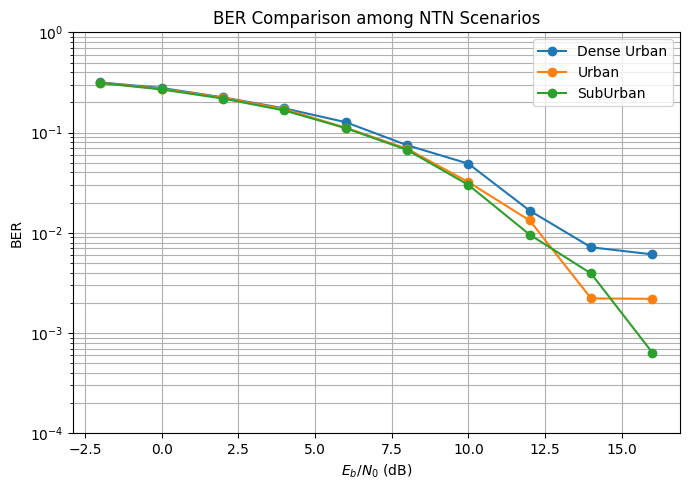

In [11]:
# Cell 8：BER 图 3 —— 三种 NTN 场景 BER 对比

scenario_results = []

scenario_cases = [
    ("Dense Urban", "dur"),
    ("Urban", "urb"),
    ("SubUrban", "sur"),
]

for label, sc in scenario_cases:
    res = run_ber_curve(
        label=label,
        scenario=sc,
        carrier_frequency=3.5e9,
        elevation_angle=50.0,
        doppler_enabled=True,
        enable_pathloss=False,
        enable_shadow_fading=False,
        perfect_csi=True,   # 修复：用 perfect CSI 展示不同场景的纯信道效应
        coded_ber=False,
        ebno_db=ebno_db,
    )
    scenario_results.append(res)

plot_ber_results(scenario_results, "BER Comparison among NTN Scenarios")

### BER 图 3 物理意义

这张图用于说明不同 NTN 场景对 BER 的影响。

一般解释：

- Dense Urban：遮挡、散射、多径更强，链路最差；
- Urban：中等；
- SubUrban：LOS 条件更好，链路更稳定。

如果曲线差异不明显，可以打开 `enable_pathloss=True` 和 `enable_shadow_fading=True` 作为补充实验，但答辩时要说明这时曲线差异包含大尺度路径损耗影响。

In [12]:
# Cell 9：可选 —— coded BER 完整链路验证

RUN_CODED_BER = False

if RUN_CODED_BER:
    coded_result = run_ber_curve(
        label="Coded BER, Dense Urban",
        scenario="dur",
        carrier_frequency=3.5e9,
        elevation_angle=50.0,
        doppler_enabled=True,
        enable_pathloss=False,
        enable_shadow_fading=False,
        perfect_csi=False,
        coded_ber=True,
        ebno_db=np.arange(0.0, 16.1, 2.0),
        batch_size=8,
        max_mc_iter=100,
        num_target_block_errors=100,
    )

    plot_ber_results([coded_result], "Coded BER with LDPC")
else:
    print("RUN_CODED_BER=False，暂不运行 coded BER。")

RUN_CODED_BER=False，暂不运行 coded BER。


### Cell 9 作用

保留完整 LDPC 编码/译码链路的入口。  
中期展示优先用 uncoded BER；coded BER 可以作为“完整链路已具备”的补充说明。

In [13]:
# Cell 10：保存全部结果，便于后续画图或写论文

all_results = {
    "doppler_on_off_results": doppler_on_off_results if "doppler_on_off_results" in globals() else None,
    "doppler_strength_results": doppler_strength_results if "doppler_strength_results" in globals() else None,
    "elevation_results": elevation_results if "elevation_results" in globals() else None,
    "scenario_results": scenario_results if "scenario_results" in globals() else None,
    "base_config": BASE_CONFIG,
}

with open("ntn_ber_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

print("Saved results to ntn_ber_results.pkl")

Saved results to ntn_ber_results.pkl


### Cell 10 作用

保存 BER 结果，避免每次写论文或改图都重新跑仿真。